In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
data = pd.read_csv("D:/LPV_Codes/2_DL/housing_data (1).csv")

In [5]:
data.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [6]:
data.fillna(data.mean(), inplace=True)

In [7]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.545770,22.921051,6.699165,0.250233,0.115878,0.702617,27.439466,2.105710,8.707259,168.537116,2.164946,91.294864,7.012739,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.083235,0.000000,5.190000,0.000000,0.449000,5.885500,45.925000,2.100175,4.000000,279.000000,17.400000,375.377500,7.230000,17.025000
50%,0.290250,0.000000,9.900000,0.000000,0.538000,6.208500,74.450000,3.207450,5.000000,330.000000,19.050000,391.440000,11.995000,21.200000
75%,3.611874,11.211934,18.100000,0.000000,0.624000,6.623500,93.575000,5.188425,24.000000,666.000000,20.200000,396.225000,16.570000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [9]:
print("First 5 rows:\n", data.head())
print("\nColumns:\n", data.columns)

First 5 rows:
       CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B      LSTAT  MEDV  
0  396.90   4.980000  24.0  
1  396.90   9.140000  21.6  
2  392.83   4.030000  34.7  
3  394.63   2.940000  33.4  
4  396.90  12.715432  36.2  

Columns:
 Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')


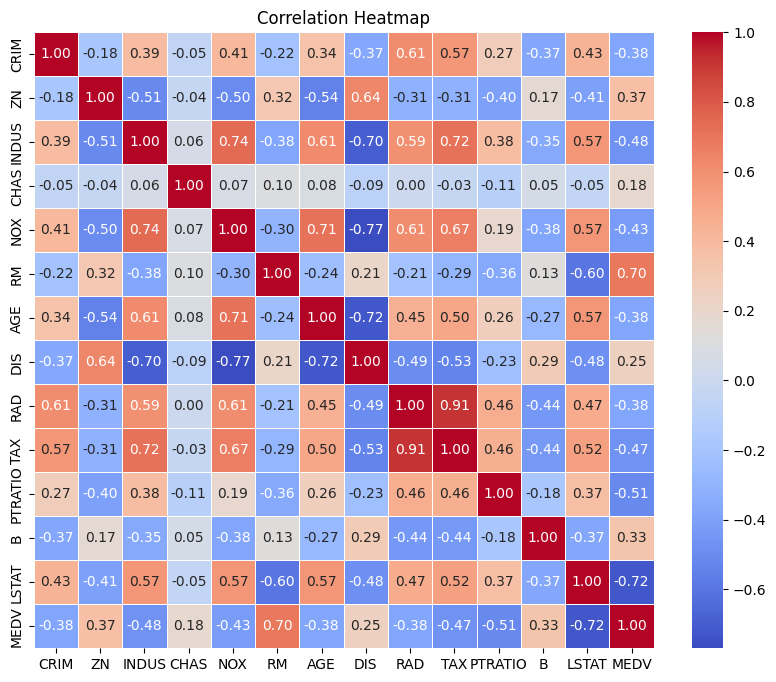

In [10]:
#Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", linewidths=0.5, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

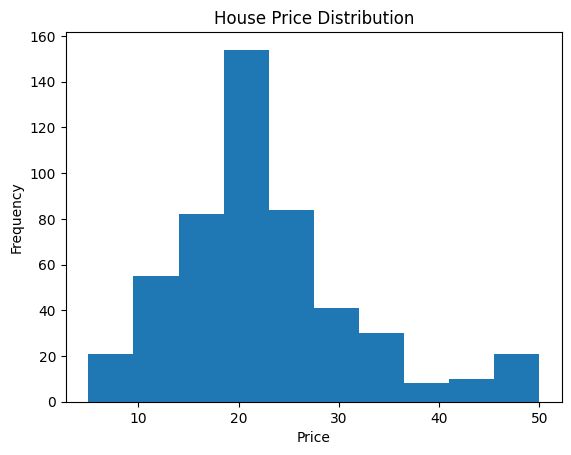

In [11]:
#histogram target distribution
plt.hist(data['MEDV'])
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [12]:
#features n target
X = data.drop('MEDV', axis=1)
y = data['MEDV']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
# Step 9: Build Model (DNN)
from tensorflow.keras import Input
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

In [17]:
# Step 11: Train
history = model.fit(X_train, y_train, epochs=50, batch_size=8)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1191.3323
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 89.4226 
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 72.7195
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 69.1416
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 65.6773
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 61.7784
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 56.7841
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 55.0149
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 49.8037
Epoch 10/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 48.8476
Epoch 11/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45.1786
Epoch 12/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 44.4271
Epoch 13/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 52.7263
Epoch 14/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40.8234
Epoch 15/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 43.5355


In [16]:
# Step 10: Compile
model.compile(optimizer='adam', loss='mse')

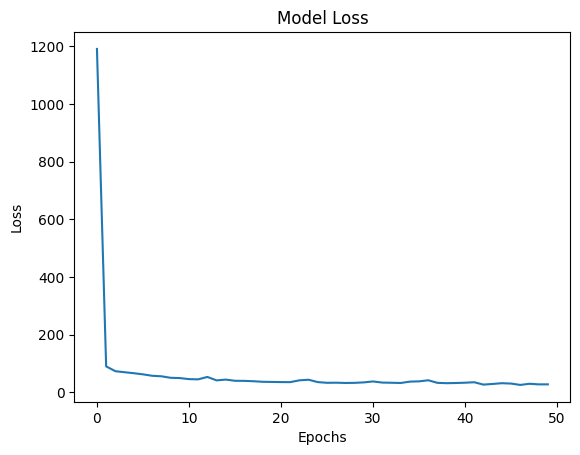

In [18]:
# Step 12: Loss Graph
plt.plot(history.history['loss'])
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [19]:
# Step 13: Evaluate
loss = model.evaluate(X_test, y_test)
print("Test Loss:", loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 52.7333 
Test Loss: 52.7332649230957


In [20]:
# Step 14: Predictions
predictions = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


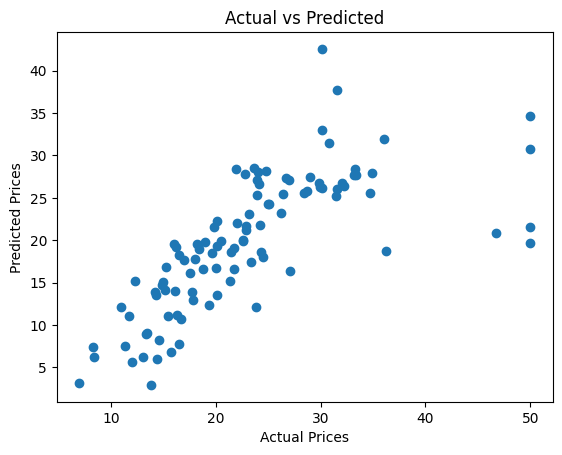

In [21]:
# Step 15: Actual vs Predicted Graph
plt.scatter(y_test, predictions)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()